# Proyek Outfit Recommendation System
- **Nama:** Vita Tri Utami
- **Email:** vitatriutami@gmail.com
- **ID Dicoding:** vitatriutami

## Import Semua Packages/Library yang Digunakan

In [1]:
# =========================================================
# IMPORT PACKAGES
# =========================================================

import os
import random
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from PIL import Image

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import LabelEncoder

import tensorflow as tf

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

import kagglehub

## Data Preparation

In [2]:
# =========================================================
# DOWNLOAD DATASET
# =========================================================

path = kagglehub.dataset_download(
    "paramaggarwal/fashion-product-images-small"
)

print(path)

100%|██████████| 565M/565M [00:04<00:00, 133MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/paramaggarwal/fashion-product-images-small/versions/1


In [3]:
# =========================================================
# CEK FOLDER DATASET
# =========================================================

os.listdir(path)

['styles.csv', 'myntradataset', 'images']

In [4]:
# =========================================================
# SET DATA DIRECTORY
# =========================================================

IMAGE_DIR = os.path.join(
    path,
    "images"
)

CSV_PATH = os.path.join(
    path,
    "styles.csv"
)

print("IMAGE_DIR:", IMAGE_DIR)
print("CSV_PATH :", CSV_PATH)

IMAGE_DIR: /root/.cache/kagglehub/datasets/paramaggarwal/fashion-product-images-small/versions/1/images
CSV_PATH : /root/.cache/kagglehub/datasets/paramaggarwal/fashion-product-images-small/versions/1/styles.csv


In [5]:
print(
    "CSV EXISTS:",
    os.path.exists(CSV_PATH)
)

print(
    "IMAGE DIR EXISTS:",
    os.path.exists(IMAGE_DIR)
)

CSV EXISTS: True
IMAGE DIR EXISTS: True


In [6]:
# =========================================================
# LOAD CSV
# =========================================================

df = pd.read_csv(
    CSV_PATH,
    on_bad_lines="skip"
)

df.head()

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt


In [7]:
# =========================================================
# CEK INFORMASI DATASET
# =========================================================

print("Jumlah Data :", len(df))

print("\nKolom:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

Jumlah Data : 44424

Kolom:
Index(['id', 'gender', 'masterCategory', 'subCategory', 'articleType',
       'baseColour', 'season', 'year', 'usage', 'productDisplayName'],
      dtype='object')

Missing Values:
id                      0
gender                  0
masterCategory          0
subCategory             0
articleType             0
baseColour             15
season                 21
year                    1
usage                 317
productDisplayName      7
dtype: int64


In [8]:
# =========================================================
# DROP MISSING VALUES
# =========================================================

important_columns = [

    "id",

    "gender",

    "masterCategory",

    "subCategory",

    "articleType",

    "baseColour",

    "season",

    "usage",

    "productDisplayName"
]

df = df.dropna(
    subset=important_columns
)

df = df.reset_index(drop=True)

print("Jumlah Data Setelah Cleaning:", len(df))

Jumlah Data Setelah Cleaning: 44077


In [9]:
# =========================================================
# BUAT IMAGE PATH
# =========================================================

df["image_path"] = df["id"].astype(str) + ".jpg"

df["image_path"] = df["image_path"].apply(
    lambda x: os.path.join(IMAGE_DIR, x)
)

In [10]:
# =========================================================
# FILTER FILE YANG BENAR-BENAR ADA
# =========================================================

df = df[
    df["image_path"].apply(os.path.exists)
]

df = df.reset_index(drop=True)

print("Jumlah Data Dengan Gambar Valid:", len(df))

Jumlah Data Dengan Gambar Valid: 44072


In [11]:
# =========================================================
# SIMPLIFIKASI DATASET UNTUK MVP
# =========================================================

allowed_categories = [

    "Apparel",

    "Footwear"
]

df = df[
    df["masterCategory"].isin(
        allowed_categories
    )
]

df = df.reset_index(drop=True)

print("Jumlah Data Setelah Filter:", len(df))

Jumlah Data Setelah Filter: 30558


In [12]:
# =========================================================
# FORMAL LEVEL MAPPING
# =========================================================

formal_map = {

    "Casual": "casual",

    "Formal": "formal",

    "Sports": "sports",

    "Ethnic": "semi_formal",

    "Smart Casual": "smart_casual"
}

df["formal_level"] = df[
    "usage"
].map(formal_map)

df["formal_level"] = df[
    "formal_level"
].fillna("casual")

In [13]:
# =========================================================
# INDOOR / OUTDOOR MAPPING
# =========================================================

indoor_outdoor_map = {

    "Formal Shoes": "indoor",

    "Blazers": "indoor",

    "Track Pants": "outdoor",

    "Sports Shoes": "outdoor",

    "Shorts": "outdoor",

    "Flip Flops": "outdoor",

    "Sweatshirts": "outdoor",

    "Sandals": "outdoor",

    "Casual Shoes": "outdoor",

    "Tshirts": "outdoor",

    "Shirts": "indoor",

    "Kurtas": "indoor"
}

df["indoor_outdoor"] = df[
    "articleType"
].map(indoor_outdoor_map)

df["indoor_outdoor"] = df[
    "indoor_outdoor"
].fillna("both")

In [14]:
# =========================================================
# BODY TYPE MAPPING
# =========================================================

body_type_map = {

    "Tshirts": [

        "rectangle",

        "pear"
    ],

    "Shirts": [

        "rectangle",

        "apple"
    ],

    "Kurtas": [

        "pear",

        "hourglass"
    ],

    "Waistcoat": [

        "rectangle",

        "apple"
    ],

    "Track Pants": [

        "rectangle",

        "hourglass"
    ],

    "Shorts": [

        "rectangle",

        "pear"
    ],

    "Sweatshirts": [

        "rectangle",

        "pear"
    ],

    "Formal Shoes": [

        "all"
    ],

    "Sports Shoes": [

        "all"
    ]
}

df["body_type_match"] = df[
    "articleType"
].map(body_type_map)

df["body_type_match"] = df[
    "body_type_match"
].apply(
    lambda x: x if isinstance(x, list)
    else ["all"]
)

In [15]:
# =========================================================
# STYLE GROUP MAPPING
# =========================================================

style_group_map = {

    "Tshirts": "minimalist",

    "Shirts": "smart_casual",

    "Track Pants": "sporty",

    "Kurtas": "ethnic",

    "Sweatshirts": "streetwear",

    "Blazers": "formal",

    "Shorts": "casual",

    "Casual Shoes": "casual",

    "Sports Shoes": "sporty"
}

df["style_group"] = df[
    "articleType"
].map(style_group_map)

df["style_group"] = df[
    "style_group"
].fillna("casual")

In [16]:
# =========================================================
# CEK HASIL METADATA ENRICHMENT
# =========================================================

df[[
    "articleType",

    "usage",

    "formal_level",

    "indoor_outdoor",

    "body_type_match",

    "style_group"
]].head(10)

,articleType,usage,formal_level,indoor_outdoor,body_type_match,style_group
0,Shirts,Casual,casual,indoor,"[rectangle, apple]",smart_casual
1,Jeans,Casual,casual,both,[all],casual
2,Track Pants,Casual,casual,outdoor,"[rectangle, hourglass]",sporty
3,Tshirts,Casual,casual,outdoor,"[rectangle, pear]",minimalist
4,Tshirts,Casual,casual,outdoor,"[rectangle, pear]",minimalist
5,Shirts,Ethnic,semi_formal,indoor,"[rectangle, apple]",smart_casual
6,Shirts,Casual,casual,indoor,"[rectangle, apple]",smart_casual
7,Casual Shoes,Casual,casual,outdoor,[all],casual
8,Flip Flops,Casual,casual,outdoor,[all],casual
9,Flip Flops,Casual,casual,outdoor,[all],casual


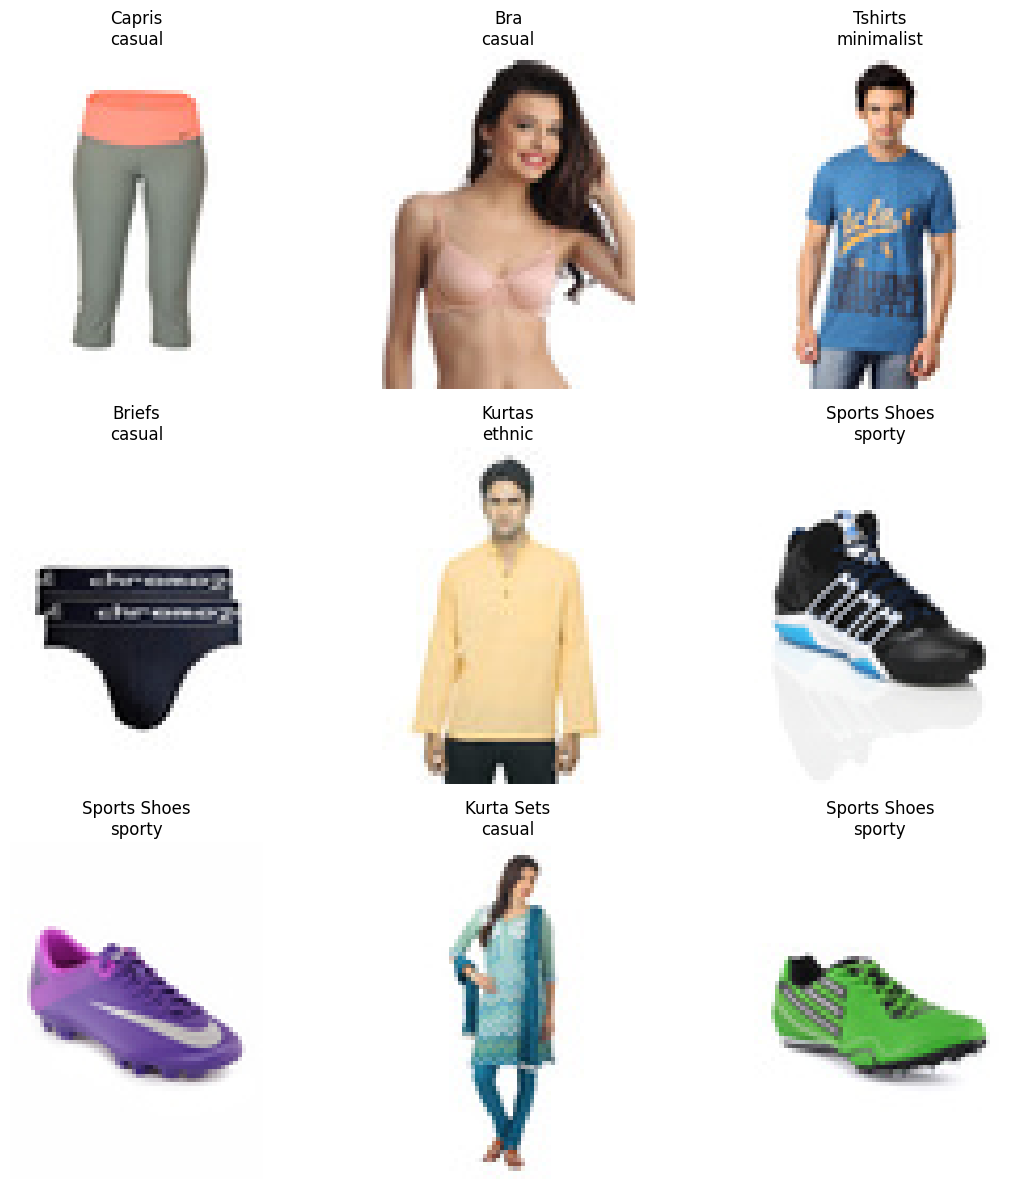

In [17]:
# =========================================================
# VISUALISASI SAMPLE DATA
# =========================================================

sample_df = df.sample(
    9,
    random_state=42
)

plt.figure(figsize=(12,12))

for i, row in enumerate(sample_df.itertuples()):

    plt.subplot(3,3,i+1)

    img = Image.open(
        row.image_path
    )

    plt.imshow(img)

    plt.title(
        f"{row.articleType}\n"
        f"{row.style_group}"
    )

    plt.axis("off")

plt.tight_layout()

plt.show()

In [18]:
# =========================================================
# LOAD MOBILENETV2 FEATURE EXTRACTOR
# =========================================================

feature_extractor = MobileNetV2(

    weights="imagenet",

    include_top=False,

    pooling="avg",

    input_shape=(224,224,3)
)

print("MobileNetV2 Loaded")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNetV2 Loaded


In [19]:
# =========================================================
# IMAGE PREPROCESS FUNCTION
# =========================================================

def preprocess_image(image_path):

    try:

        img = tf.keras.utils.load_img(

            image_path,

            target_size=(224,224)
        )

        img_array = tf.keras.utils.img_to_array(img)

        img_array = np.expand_dims(
            img_array,
            axis=0
        )

        img_array = preprocess_input(
            img_array
        )

        return img_array

    except:

        return None

In [20]:
# =========================================================
# FEATURE EXTRACTION FUNCTION
# =========================================================

def extract_embedding(image_path):

    img_array = preprocess_image(
        image_path
    )

    if img_array is None:

        return None

    embedding = feature_extractor.predict(
        img_array,
        verbose=0
    )

    return embedding.flatten()

In [21]:
# =========================================================
# AMBIL SAMPLE DATA UNTUK MVP DEMO
# =========================================================

mvp_df = df.sample(
    500,
    random_state=42
).reset_index(drop=True)

print(len(mvp_df))

500


In [22]:
# =========================================================
# GENERATE VISUAL EMBEDDINGS
# =========================================================

embeddings = []

for path in mvp_df["image_path"]:

    emb = extract_embedding(path)

    embeddings.append(emb)

mvp_df["embedding"] = embeddings

print("Embedding selesai dibuat")

Embedding selesai dibuat


## Save Deployment Assets

Save image_file

In [23]:
mvp_df["image_file"] = mvp_df[
    "image_path"
].apply(os.path.basename)

Save subset images (used images)

In [24]:
import shutil

TARGET_IMAGE_DIR = "images"

os.makedirs(
    TARGET_IMAGE_DIR,
    exist_ok=True
)

for path in mvp_df["image_path"]:

    if os.path.exists(path):

        filename = os.path.basename(path)

        shutil.copy(
            path,
            os.path.join(
                TARGET_IMAGE_DIR,
                filename
            )
        )

Save Embeddings

In [25]:
embeddings_array = np.array(
    mvp_df["embedding"].tolist()
)

np.save(
    "fashion_embeddings.npy",
    embeddings_array
)

print("Embeddings berhasil disimpan")

Embeddings berhasil disimpan


Save Embedding Index

In [26]:
# =========================================================
# SAVE EMBEDDING INDEX
# =========================================================

mvp_df["embedding_idx"] = np.arange(len(mvp_df))

Save Lightweight Metadata

In [27]:
metadata_df = mvp_df[[
    "embedding_idx",
    "id",
    "productDisplayName",
    "masterCategory",
    "subCategory",
    "articleType",
    "baseColour",
    "season",
    "usage",
    "gender",
    "formal_level",
    "indoor_outdoor",
    "style_group",
    "body_type_match",
    "image_file"
]]

Save CSV

In [28]:
metadata_df.to_csv(
    "products.csv",
    index=False
)

print("Metadata berhasil disimpan")

Metadata berhasil disimpan


Save Model

In [29]:
feature_extractor.save(
    "mobilenet_feature_extractor.keras"
)

print("Model berhasil disimpan")

Model berhasil disimpan


## Inference

In [30]:
# =========================================================
# USER INPUT SIMULATION
# =========================================================

user_body_type = "pear"

user_formality = "casual"

user_activity = "outdoor"

preferred_style = "minimalist"

In [31]:
# =========================================================
# RULE-BASED FILTERING
# =========================================================

filtered_df = mvp_df[

    (mvp_df["formal_level"] == user_formality)

    &

    (
        mvp_df["indoor_outdoor"].isin(
            [user_activity, "both"]
        )
    )
]

filtered_df = filtered_df[

    filtered_df[
        "body_type_match"
    ].apply(

        lambda x:
        user_body_type in x
        or "all" in x
    )
]

filtered_df = filtered_df.reset_index(drop=True)

print("Jumlah Kandidat:", len(filtered_df))

Jumlah Kandidat: 334


In [32]:
# =========================================================
# SCORING SYSTEM
# =========================================================

def calculate_score(row):

    score = 0

    # BODY MATCH
    if (
        user_body_type
        in row["body_type_match"]
    ):

        score += 0.4

    # STYLE MATCH
    if (
        row["style_group"]
        == preferred_style
    ):

        score += 0.3

    # CONTEXT MATCH
    if (
        row["formal_level"]
        == user_formality
    ):

        score += 0.2

    # INDOOR / OUTDOOR
    if (
        row["indoor_outdoor"]
        in [user_activity, "both"]
    ):

        score += 0.1

    return score

In [33]:
# =========================================================
# HITUNG SCORE
# =========================================================

filtered_df["score"] = filtered_df.apply(
    calculate_score,
    axis=1
)

filtered_df = filtered_df.sort_values(
    by="score",
    ascending=False
)

filtered_df.head()

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName,image_path,formal_level,indoor_outdoor,body_type_match,style_group,embedding,image_file,embedding_idx,score
125,2006,Men,Apparel,Topwear,Tshirts,White,Fall,2010.0,Casual,Puma Men's African Splash T-shirt,/root/.cache/kagglehub/datasets/paramaggarwal/...,casual,outdoor,"[rectangle, pear]",minimalist,"[0.12661101, 0.009921726, 0.15946165, 0.092545...",2006.jpg,181,1.0
248,52136,Women,Apparel,Topwear,Tshirts,Black,Summer,2012.0,Casual,Femella Women Black Polo T-Shirt,/root/.cache/kagglehub/datasets/paramaggarwal/...,casual,outdoor,"[rectangle, pear]",minimalist,"[0.17987394, 0.0, 0.0, 0.52376777, 0.001198622...",52136.jpg,369,1.0
251,57932,Men,Apparel,Topwear,Tshirts,White,Summer,2012.0,Casual,French Connection Men White T-shirt,/root/.cache/kagglehub/datasets/paramaggarwal/...,casual,outdoor,"[rectangle, pear]",minimalist,"[0.84387535, 0.0, 0.05606285, 0.38425952, 0.0,...",57932.jpg,373,1.0
254,23158,Men,Apparel,Topwear,Tshirts,Grey,Fall,2011.0,Casual,Mark Taylor Men Grey Printed T-shirt,/root/.cache/kagglehub/datasets/paramaggarwal/...,casual,outdoor,"[rectangle, pear]",minimalist,"[0.3940874, 0.0, 0.0, 0.0, 0.0, 0.0, 0.6807562...",23158.jpg,376,1.0
255,9856,Men,Apparel,Topwear,Tshirts,Red,Fall,2011.0,Casual,Status Quo Men Red Polo Tshirts,/root/.cache/kagglehub/datasets/paramaggarwal/...,casual,outdoor,"[rectangle, pear]",minimalist,"[0.22382458, 0.0, 0.13639294, 0.74552727, 0.0,...",9856.jpg,377,1.0


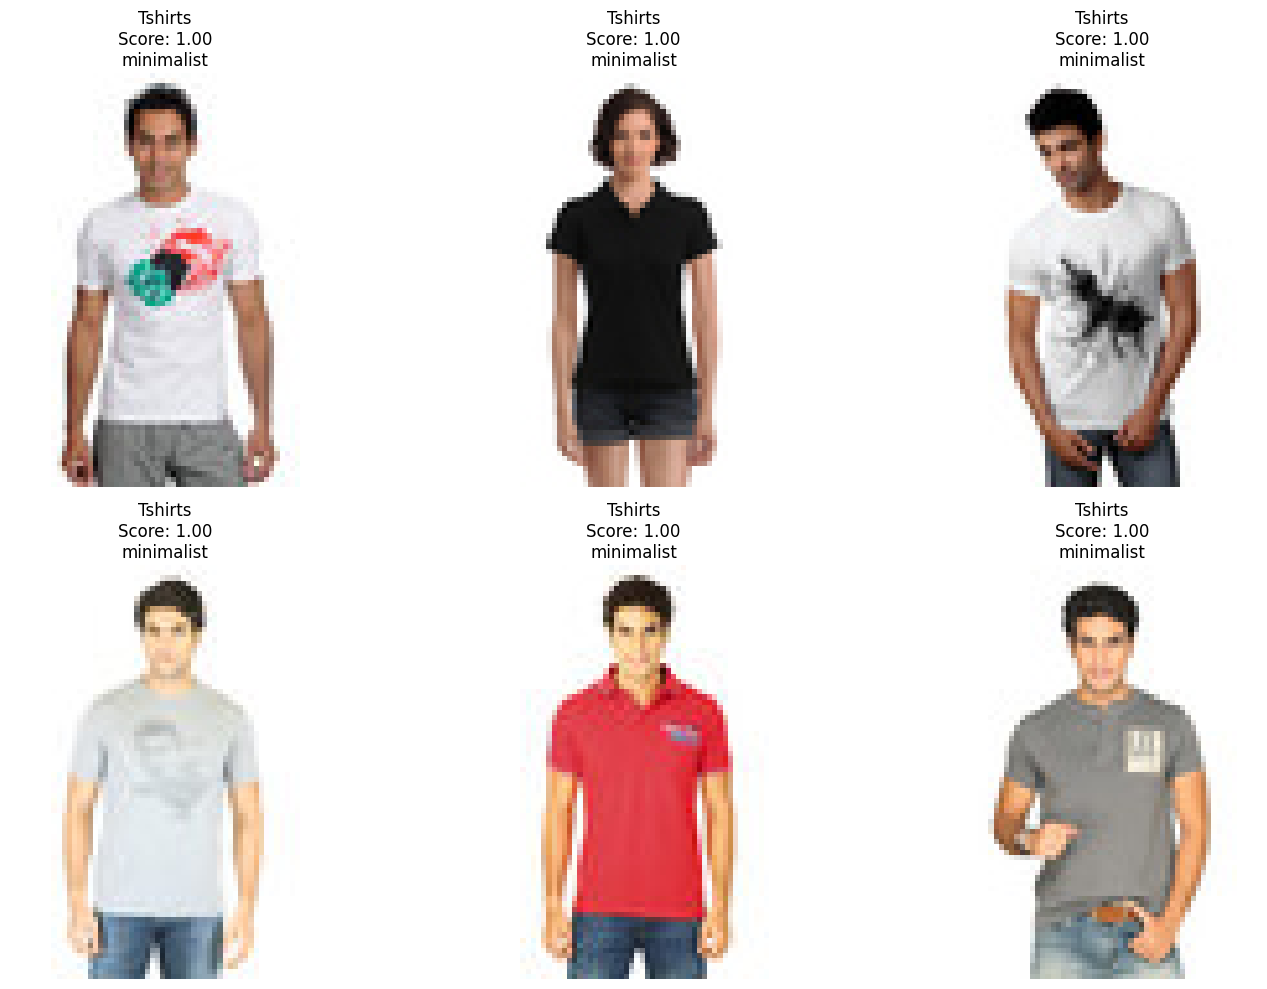

In [34]:
# =========================================================
# TAMPILKAN TOP RECOMMENDATIONS
# =========================================================

top_n = 6

top_df = filtered_df.head(top_n)

plt.figure(figsize=(15,10))

for i, row in enumerate(top_df.itertuples()):

    plt.subplot(2,3,i+1)

    img = Image.open(
        row.image_path
    )

    plt.imshow(img)

    plt.title(
        f"{row.articleType}\n"
        f"Score: {row.score:.2f}\n"
        f"{row.style_group}"
    )

    plt.axis("off")

plt.tight_layout()

plt.show()

In [35]:
# =========================================================
# COSINE SIMILARITY FUNCTION
# =========================================================

def get_similarity(
    emb1,
    emb2
):

    emb1 = emb1.reshape(1,-1)

    emb2 = emb2.reshape(1,-1)

    similarity = cosine_similarity(
        emb1,
        emb2
    )[0][0]

    return similarity

In [36]:
# =========================================================
# PILIH REFERENCE ITEM
# =========================================================

reference_index = 0

reference_embedding = filtered_df.iloc[
    reference_index
]["embedding"]

reference_image = filtered_df.iloc[
    reference_index
]["image_path"]

print(
    filtered_df.iloc[
        reference_index
    ]["productDisplayName"]
)

Puma Men's African Splash T-shirt


In [37]:
# =========================================================
# HITUNG VISUAL SIMILARITY
# =========================================================

similarities = []

for emb in filtered_df["embedding"]:

    sim = get_similarity(
        reference_embedding,
        emb
    )

    similarities.append(sim)

filtered_df[
    "visual_similarity"
] = similarities

In [38]:
# =========================================================
# FINAL HYBRID SCORE
# =========================================================

filtered_df["final_score"] = (

    0.7 * filtered_df["score"]

    +

    0.3 * filtered_df[
        "visual_similarity"
    ]
)

In [39]:
# =========================================================
# SORT FINAL RECOMMENDATION
# =========================================================

filtered_df = filtered_df.sort_values(

    by="final_score",

    ascending=False
)

filtered_df.head()

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName,...,formal_level,indoor_outdoor,body_type_match,style_group,embedding,image_file,embedding_idx,score,visual_similarity,final_score
125,2006,Men,Apparel,Topwear,Tshirts,White,Fall,2010.0,Casual,Puma Men's African Splash T-shirt,...,casual,outdoor,"[rectangle, pear]",minimalist,"[0.12661101, 0.009921726, 0.15946165, 0.092545...",2006.jpg,181,1.0,1.000000,1.000000
60,24269,Men,Apparel,Topwear,Tshirts,Grey,Fall,2011.0,Casual,Quiksilver Men Grey Printed T-shirt,...,casual,outdoor,"[rectangle, pear]",minimalist,"[1.0489794, 0.0, 0.0, 0.21745308, 0.01094172, ...",24269.jpg,85,1.0,0.792408,0.937722
217,5867,Men,Apparel,Topwear,Tshirts,White,Summer,2011.0,Casual,ADIDAS Men's Master Shoe White T-shirt,...,casual,outdoor,"[rectangle, pear]",minimalist,"[0.9425927, 0.0, 0.0, 0.436512, 0.0, 0.0100052...",5867.jpg,317,1.0,0.788478,0.936543
7,4058,Men,Apparel,Topwear,Tshirts,White,Summer,2011.0,Casual,Myntra Men's Drink N Drive White T-shirt,...,casual,outdoor,"[rectangle, pear]",minimalist,"[0.7478068, 0.0, 0.0, 0.001518123, 0.0, 0.0183...",4058.jpg,13,1.0,0.785493,0.935648
272,13954,Men,Apparel,Topwear,Tshirts,White,Summer,2011.0,Casual,United Colors of Benetton Men Printed White P...,...,casual,outdoor,"[rectangle, pear]",minimalist,"[0.63353294, 0.0047763903, 0.023802698, 0.0128...",13954.jpg,410,1.0,0.766528,0.929958


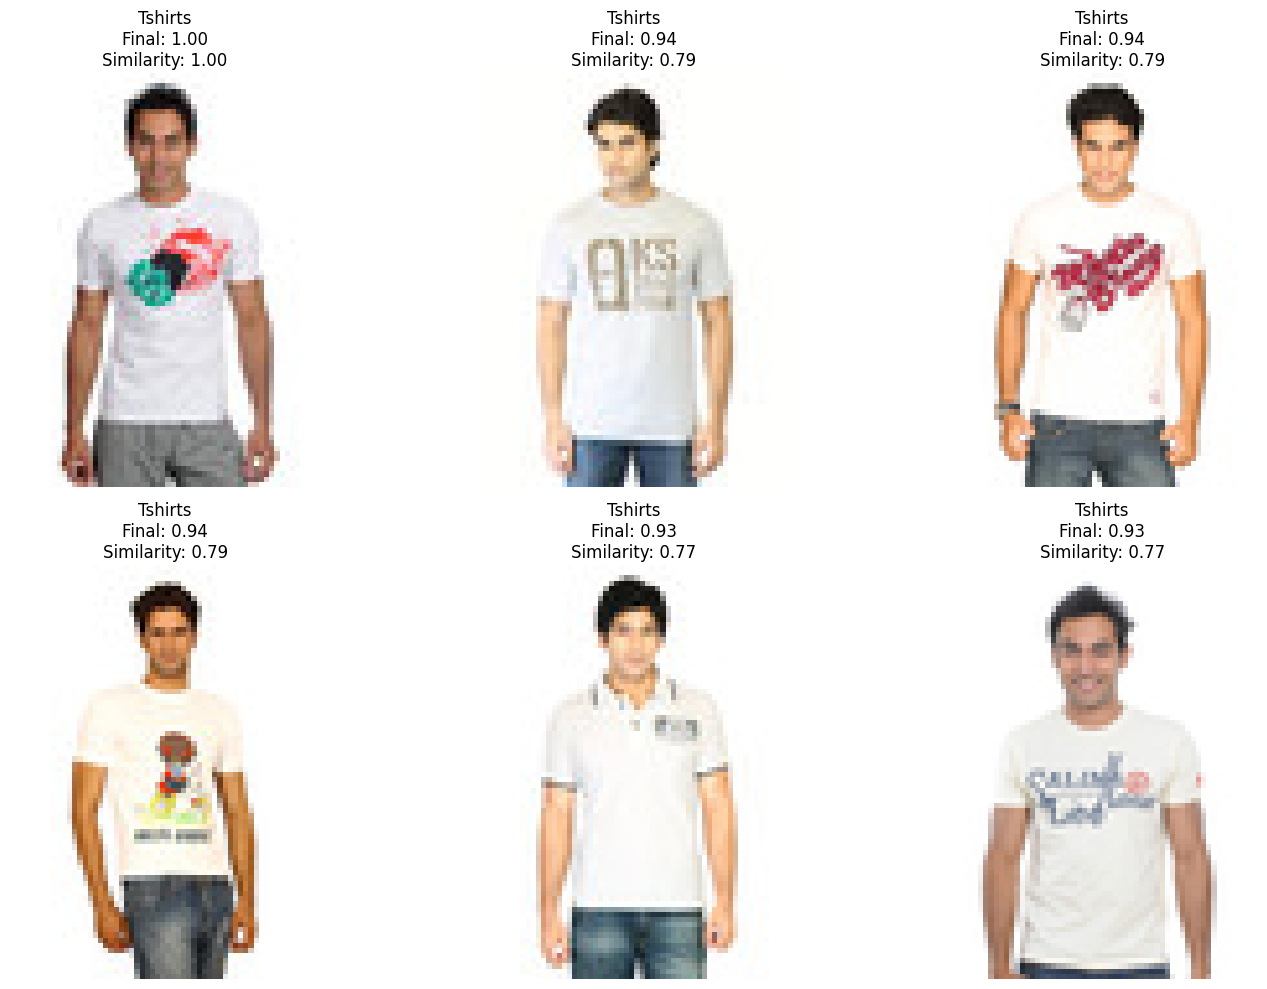

In [40]:
# =========================================================
# FINAL RECOMMENDATION DISPLAY
# =========================================================

top_n = 6

top_df = filtered_df.head(top_n)

plt.figure(figsize=(15,10))

for i, row in enumerate(top_df.itertuples()):

    plt.subplot(2,3,i+1)

    img = Image.open(
        row.image_path
    )

    plt.imshow(img)

    plt.title(

        f"{row.articleType}\n"

        f"Final: {row.final_score:.2f}\n"

        f"Similarity: {row.visual_similarity:.2f}"
    )

    plt.axis("off")

plt.tight_layout()

plt.show()

In [41]:
# =========================================================
# EXPLAINABILITY FUNCTION
# =========================================================

def generate_explanation(row):

    reasons = []

    if (
        user_body_type
        in row["body_type_match"]
    ):

        reasons.append(
            "Suitable for body type"
        )

    if (
        row["formal_level"]
        == user_formality
    ):

        reasons.append(
            "Matches activity context"
        )

    if (
        row["style_group"]
        == preferred_style
    ):

        reasons.append(
            "Consistent style"
        )

    if (
        row["visual_similarity"]
        > 0.75
    ):

        reasons.append(
            "High visual similarity"
        )

    return reasons

In [42]:
filtered_df["explanation"] = filtered_df.apply(

    generate_explanation,

    axis=1
)

In [43]:
filtered_df[[

    "productDisplayName",

    "final_score",

    "explanation"

]].head()

,productDisplayName,final_score,explanation
125,Puma Men's African Splash T-shirt,1.000000,"[Suitable for body type, Matches activity cont..."
60,Quiksilver Men Grey Printed T-shirt,0.937722,"[Suitable for body type, Matches activity cont..."
217,ADIDAS Men's Master Shoe White T-shirt,0.936543,"[Suitable for body type, Matches activity cont..."
7,Myntra Men's Drink N Drive White T-shirt,0.935648,"[Suitable for body type, Matches activity cont..."
272,United Colors of Benetton Men Printed White P...,0.929958,"[Suitable for body type, Matches activity cont..."


## ---

In [44]:
# =========================================================
# SAVE FINAL DATAFRAME
# =========================================================
'''
filtered_df.to_pickle(
    "fashion_recommendation.pkl"
)

print(
    "DataFrame berhasil disimpan"
)
'''

'\nfiltered_df.to_pickle(\n    "fashion_recommendation.pkl"\n)\n\nprint(\n    "DataFrame berhasil disimpan"\n)\n'

In [45]:
filtered_df.columns

Index(['id', 'gender', 'masterCategory', 'subCategory', 'articleType',
       'baseColour', 'season', 'year', 'usage', 'productDisplayName',
       'image_path', 'formal_level', 'indoor_outdoor', 'body_type_match',
       'style_group', 'embedding', 'image_file', 'embedding_idx', 'score',
       'visual_similarity', 'final_score', 'explanation'],
      dtype='object')

## Structuring Project Output

In [46]:
import pickle
import zipfile
from google.colab import files

In [48]:
# =========================================================
# BUAT STRUKTUR PROJECT
# =========================================================

import os
import shutil

PROJECT_NAME = "VARStyle_MVP_V3"

os.makedirs(PROJECT_NAME, exist_ok=True)

# Copy dataframe
'''
shutil.copy(
    "fashion_recommendation.pkl",
    f"{PROJECT_NAME}/fashion_recommendation.pkl"
)
'''

# Copy embeddings
shutil.copy(
    "fashion_embeddings.npy",
    f"{PROJECT_NAME}/fashion_embeddings.npy"
)

# Copy keras model file
shutil.copy(
    "mobilenet_feature_extractor.keras",
    f"{PROJECT_NAME}/mobilenet_feature_extractor.keras"
)

# Copy folder images
shutil.copytree(
    "images",
    f"{PROJECT_NAME}/images"
)

# Copy CSV file
shutil.copy(
    "products.csv",
    f"{PROJECT_NAME}/products.csv"
)

print("Project structure berhasil dibuat")

Project structure berhasil dibuat


In [49]:
# =========================================================
# ZIP PROJECT
# =========================================================

zip_name = "VARStyle_MVP_V3.zip"

with zipfile.ZipFile(
    zip_name,
    "w",
    zipfile.ZIP_DEFLATED
) as zipf:

    for root, dirs, files_in_dir in os.walk(PROJECT_NAME):

        for file in files_in_dir:

            file_path = os.path.join(
                root,
                file
            )

            arcname = os.path.relpath(
                file_path,
                PROJECT_NAME
            )

            zipf.write(
                file_path,
                arcname
            )

print("ZIP berhasil dibuat")

ZIP berhasil dibuat


In [50]:
# =========================================================
# DOWNLOAD ZIP
# =========================================================

files.download(
    "VARStyle_MVP_V3.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>